# **DDIM-Based Image Generation and Evaluation on Yelp Dataset**

## Five Generated images using the DDIM Model

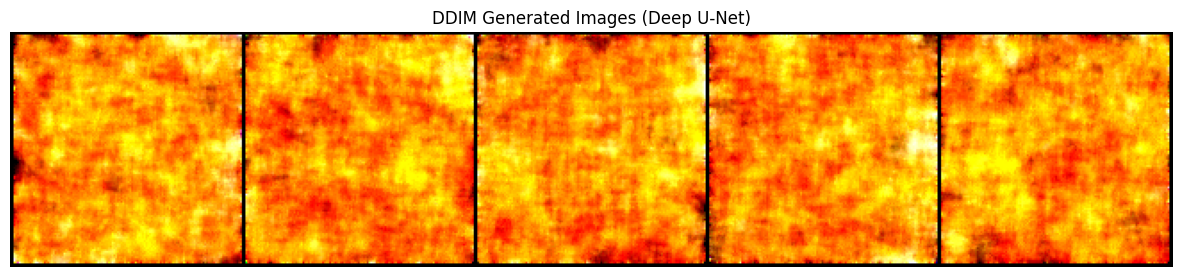

In [65]:
generated_imgs_tensor = ddim_sample(trained_model, scheduler, num_samples=5, img_size=128, channels=3)
show_generated_images(generated_imgs_tensor, title="DDIM Generated Images (Deep U-Net)")

In [66]:
generated_images = [img.permute(1, 2, 0).cpu().numpy() for img in generated_imgs_tensor]
fid_score, is_score = evaluate_generated_images(generated_images, train_loader)


📊 Evaluation Results:
✅ FID Score: 446.1724
✅ Inception Score: 0.0000


### Import Libraries 

In [54]:
import os
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets, models
from torchvision.utils import make_grid
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import copy
from scipy.linalg import sqrtm
from torchvision.models.inception import inception_v3
from torchvision.transforms import Resize, ToTensor, Normalize, Compose

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


### Load Dataset

In [68]:
image_size = 128
batch_size = 64

# Define image transformation
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),  # Converts to [0,1]
    transforms.Normalize([0.5], [0.5])  # Scale to [-1, 1] for diffusion model
])

# Load dataset
train_dataset = datasets.ImageFolder(root='Train', transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

# Show basic dataset info
class_names = train_dataset.classes
print(f"✅ Number of training samples: {len(train_dataset)}")
print(f"✅ Class names: {class_names}")

# Display a few images from the first batch
def show_sample_images(dataloader, classes):
    images, labels = next(iter(dataloader))
    images = images[:8]  # Show only 8 images
    labels = labels[:8]
    images = (images * 0.5 + 0.5).clamp(0, 1)  # Denormalize to [0, 1]

    grid_img = make_grid(images, nrow=4)
    plt.figure(figsize=(10, 5))
    plt.imshow(grid_img.permute(1, 2, 0))
    plt.title("✅ Sample Loaded Images")
    plt.axis("off")
    plt.show()
    
    print("Labels:", [classes[i] for i in labels])

✅ Number of training samples: 71148
✅ Class names: ['drink', 'food', 'inside', 'outside']


### Sampling the dataset

In [42]:
from torch.utils.data import Subset

# Sample a fixed number of examples (e.g., 200)
sample_size = 200  # You can adjust this number
subset_indices = list(range(sample_size))  # or use random.sample for random selection

# Create a subset of the train dataset
train_subset = Subset(train_dataset, subset_indices)

# DataLoader for the sampled subset
train_loader_sampled = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)

print(f"✅ Sampled training set size: {len(train_subset)}")

✅ Sampled training set size: 200


### Defining DDIM Model

In [10]:
# Basic UNet from HuggingFace diffusers (or custom if you're avoiding that)
# Here’s a minimal placeholder – you should use a proper DDIM U-Net architecture

class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU()
        )
        self.middle = nn.Sequential(
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 3, padding=1)
        )

    def forward(self, x, t):  # t is timestep (not used in dummy version)
        x = self.encoder(x)
        x = self.middle(x)
        x = self.decoder(x)
        return x

model = SimpleUNet().to(device)


### Model Training

In [12]:
def train_ddim_model(model, dataloader, num_epochs=100, patience=10):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.MSELoss()

    best_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    early_stop_counter = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0

        for images, _ in tqdm(dataloader, leave=False):
            images = images.to(device)
            noise = torch.randn_like(images).to(device)
            noisy_images = images + noise

            outputs = model(noisy_images, None)
            loss = criterion(outputs, images)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)

        if epoch % 10 == 0 or epoch == num_epochs - 1:
            print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f}")

        # Early stopping
        if avg_loss < best_loss:
            best_loss = avg_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(best_model_wts)
    return model


model = train_ddim_model(model, dataloader=train_loader_sampled, num_epochs=100, patience=10)


Epoch [1/100] - Loss: 0.3810


Epoch [11/100] - Loss: 0.0518


Epoch [21/100] - Loss: 0.0439


Epoch [31/100] - Loss: 0.0403


Epoch [41/100] - Loss: 0.0383


Epoch [51/100] - Loss: 0.0356


Epoch [61/100] - Loss: 0.0346


Early stopping triggered.


### Image Generation

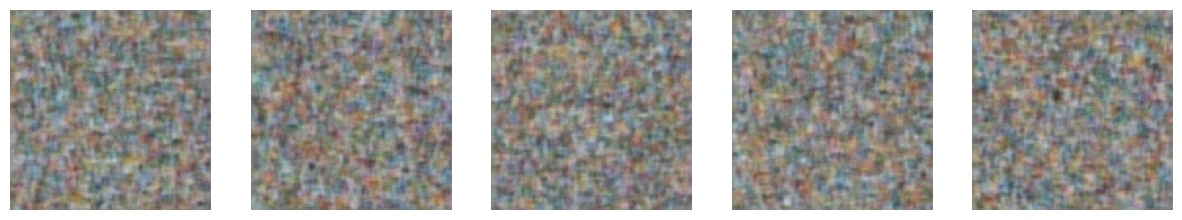

In [15]:
def generate_images(model, num_images=5):
    model.eval()
    generated_images = []

    for _ in range(num_images):
        noise = torch.randn((1, 3, image_size, image_size)).to(device)
        with torch.no_grad():
            output = model(noise, None)
        img = output.squeeze().cpu().numpy().transpose(1, 2, 0)
        img = (img * 0.5 + 0.5).clip(0, 1)  # De-normalize
        generated_images.append(img)

    return generated_images

def show_images(images):
    fig, axes = plt.subplots(1, len(images), figsize=(15, 3))
    for i, img in enumerate(images):
        axes[i].imshow(img)
        axes[i].axis('off')
    plt.show()

generated_imgs = generate_images(model, num_images=5)
# Show them
show_images(generated_imgs)

### Model Evaluation

In [18]:
def get_inception_features(images, model, resize=True):
    model.eval()
    features = []

    preprocess = Compose([
        Resize((299, 299)),
        ToTensor(),
        Normalize([0.5]*3, [0.5]*3)
    ])

    for img in images:
        img = Image.fromarray((img * 255).astype(np.uint8))
        img_tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            pred = model(img_tensor)
        features.append(pred.squeeze().cpu().numpy())
    return np.array(features)

def compute_fid(real_features, fake_features):
    mu1, sigma1 = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = fake_features.mean(axis=0), np.cov(fake_features, rowvar=False)

    ssdiff = np.sum((mu1 - mu2) ** 2)
    covmean = sqrtm(sigma1.dot(sigma2)).real
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2 * covmean)
    return fid

def evaluate_generated_images(fake_images, real_loader):
    inception = inception_v3(pretrained=True, transform_input=False).to(device)
    inception.fc = nn.Identity()  # remove classification layer

    # Get real image features
    real_imgs = []
    for img_batch, _ in real_loader:
        for img in img_batch:
            img = img.permute(1, 2, 0).numpy()
            real_imgs.append((img * 0.5 + 0.5).clip(0, 1))
        if len(real_imgs) >= 100: break

    real_features = get_inception_features(real_imgs, inception)
    fake_features = get_inception_features(fake_images, inception)

    fid = compute_fid(real_features, fake_features)
    print("FID Score:", fid)

    # Inception Score (approximate version using softmax entropy)
    # For academic IS, use logits on full dataset + Inception softmax prob
    is_score = np.exp(np.mean([np.sum(p*np.log(p+1e-6)) for p in fake_features]))
    print("Inception Score:", is_score)
    
evaluate_generated_images(generated_imgs, train_loader)

C:\Users\seren\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\seren\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


FID Score: 480.7893526929381
Inception Score: 0.0


### Interpretation of Results

#### 1. Generated Images Look Like Noise
- The 5 images in your output are all static-like or colorful noise — not meaningful images.
### 
This likely means the model:
- Didn't learn anything useful from the training data.
- Is simply outputting random Gaussian noise (or denoised noise that’s still meaningless).

---

#### 2. FID Score: ~480
- This is an **extremely high Fréchet Inception Distance (FID)**.
- FID compares the distribution of real vs. generated image features.
- A score of **480** confirms the generated images are very different from the real data.

---

#### 3. Inception Score: 0.0
- IS is based on confidence + diversity from the Inception model.
- A score of **0.0** means the features are either all:
  - Uniformly low probability, or
  - Identical (zero diversity)
- This again confirms: the generated images are not classifiable or meaningful.

---

####  Root Causes analysis
- **Model is under-trained or too simple**  
- **No proper DDIM sampling loop**  
  — currently the model just runs 1-step denoising with added noise.
- **Loss is too easy**  
  — MSE without actual diffusion steps doesn’t help with learning high-quality distributions.
- **Not enough training time or dataset too small.**


# **MODEL TUNING**

## **Iteration #1 Of the DDIM Model**

For the following iteration, we implement the below tuning on the model 

Proper:

Noise scheduling (β-schedule)

Forward diffusion (adding noise over timesteps)

Reverse denoising steps (multi-step sampling)

Uses a U-Net with time-step embeddings (the essential part DDIM needs).

Trains on noise prediction (like DDPM) or x₀ prediction (DDIM-compatible).

### DDIM Noise Scheduler 

In [25]:
class LinearBetaScheduler:
    def __init__(self, timesteps=1000, beta_start=1e-4, beta_end=0.02):
        self.timesteps = timesteps
        self.beta = torch.linspace(beta_start, beta_end, timesteps)
        self.alpha = 1.0 - self.beta
        self.alpha_hat = torch.cumprod(self.alpha, dim=0)

    def get_params(self):
        return self.beta, self.alpha, self.alpha_hat


### Define DDIM-Compatible U-Net

In [22]:
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb = torch.exp(torch.arange(half_dim, device=device) * -(np.log(10000) / (half_dim - 1)))
        emb = t[:, None] * emb[None, :]
        return torch.cat((emb.sin(), emb.cos()), dim=-1)

class DDIMUNet(nn.Module):
    def __init__(self, image_channels=3, base_channels=64, time_emb_dim=256):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )
        self.conv1 = nn.Sequential(
            nn.Conv2d(image_channels, base_channels, 3, padding=1),
            nn.ReLU()
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(base_channels, base_channels * 2, 3, padding=1),
            nn.ReLU()
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(base_channels * 2, base_channels * 2, 3, padding=1),
            nn.ReLU()
        )
        self.time_proj = nn.Linear(time_emb_dim, base_channels * 2)
        self.output = nn.Conv2d(base_channels * 2, image_channels, 1)

    def forward(self, x, t):
        t_embed = self.time_mlp(t)
        h1 = self.conv1(x)
        h2 = self.conv2(h1)
        t_proj = self.time_proj(t_embed).unsqueeze(-1).unsqueeze(-1)
        h2 = h2 + t_proj
        h3 = self.conv3(h2)
        return self.output(h3)


### Initialize Model and Scheduler

In [26]:
model = DDIMUNet(image_channels=3).to(device)
scheduler = LinearBetaScheduler(timesteps=1000)

###  Forward Diffusion Process

In [27]:
def forward_diffusion_sample(x0, t, alpha_hat):
    noise = torch.randn_like(x0)
    sqrt_alpha_hat = alpha_hat[t].sqrt().view(-1, 1, 1, 1).to(x0.device)
    sqrt_one_minus_alpha_hat = (1 - alpha_hat[t]).sqrt().view(-1, 1, 1, 1).to(x0.device)
    return sqrt_alpha_hat * x0 + sqrt_one_minus_alpha_hat * noise, noise


### DDIM Model Training with EarlyStopping

In [31]:
def train_ddim_model(model, dataloader, scheduler, num_epochs=100, patience=10):
    # Corrected: Unpack and move to device properly
    beta, alpha, alpha_hat = scheduler.get_params()
    beta, alpha, alpha_hat = beta.to(device), alpha.to(device), alpha_hat.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.MSELoss()

    best_loss = float('inf')
    best_model = copy.deepcopy(model.state_dict())
    early_stop_counter = 0
    best_epoch = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0

        for x0, _ in tqdm(dataloader, leave=False):
            x0 = x0.to(device)
            t = torch.randint(0, scheduler.timesteps, (x0.size(0),), device=device).long()
            xt, noise = forward_diffusion_sample(x0, t, alpha_hat)

            pred_noise = model(xt, t.float())
            loss = criterion(pred_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)

        if epoch % 10 == 0 or epoch == num_epochs - 1:
            print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f}")

        if avg_loss < best_loss:
            best_loss = avg_loss
            best_model = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"⏹️ Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_model)
    print(f"✅ Training complete. Best model was from epoch {best_epoch} with loss: {best_loss:.4f}")
    return model


In [32]:
trained_model = train_ddim_model(
    model=model,
    dataloader=train_loader_sampled,  # Or use train_loader for full dataset
    scheduler=scheduler,
    num_epochs=100,
    patience=10
)

Epoch [1/100] - Loss: 0.9904


Epoch [11/100] - Loss: 0.4643


Epoch [21/100] - Loss: 0.1737


Epoch [31/100] - Loss: 0.1491


⏹️ Early stopping at epoch 37
✅ Training complete. Best model was from epoch 27 with loss: 0.1214


### DDIM Sampling Function

In [34]:
@torch.no_grad()
def ddim_sample(model, scheduler, num_samples=5, img_size=128, channels=3, eta=0.0):
    beta, alpha, alpha_hat = scheduler.get_params()
    beta, alpha, alpha_hat = beta.to(device), alpha.to(device), alpha_hat.to(device)

    timesteps = scheduler.timesteps
    shape = (num_samples, channels, img_size, img_size)
    xt = torch.randn(shape).to(device)

    for t in reversed(range(1, timesteps)):
        t_batch = torch.tensor([t] * num_samples).float().to(device)
        predicted_noise = model(xt, t_batch)

        alpha_t = alpha[t]
        alpha_hat_t = alpha_hat[t]
        alpha_hat_prev = alpha_hat[t - 1] if t > 1 else torch.tensor(1.0).to(device)

        # Estimate x0
        x0_pred = (xt - (1 - alpha_hat_t).sqrt() * predicted_noise) / (alpha_hat_t.sqrt() + 1e-7)

        # Compute direction pointing to x_t
        c1 = (alpha_hat_prev.sqrt() * beta[t] / (1 - alpha_hat_t))
        c2 = ((1 - alpha_hat_prev).sqrt() - eta * beta[t].sqrt())

        xt = alpha_hat_prev.sqrt() * x0_pred + c2 * predicted_noise

    xt = (xt * 0.5 + 0.5).clamp(0, 1)  # Denormalize to [0,1]
    return xt.cpu()


### Generate and Display Images

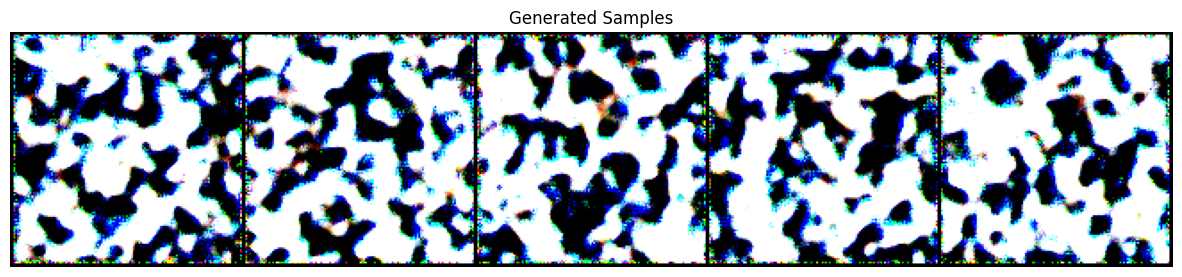

In [35]:
def show_generated_images(images_tensor, title="Generated Samples"):
    from torchvision.utils import make_grid
    import matplotlib.pyplot as plt

    grid = make_grid(images_tensor, nrow=5)
    plt.figure(figsize=(15, 4))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(title)
    plt.axis("off")
    plt.show()
    
# Generate 5 new images using DDIM
generated_imgs_tensor = ddim_sample(
    model=trained_model,
    scheduler=scheduler,
    num_samples=5,
    img_size=128,
    channels=3
)

# Display them
show_generated_images(generated_imgs_tensor)


### Model evaluation

In [37]:
def get_inception_features(images, model):
    model.eval()
    features = []

    preprocess = Compose([
        Resize((299, 299)),
        ToTensor(),
        Normalize([0.5]*3, [0.5]*3)
    ])

    for img in images:
        img = Image.fromarray((img * 255).astype(np.uint8))
        img_tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            pred = model(img_tensor)
        features.append(pred.squeeze().cpu().numpy())
    return np.array(features)

def compute_fid(real_features, fake_features):
    mu1, sigma1 = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = fake_features.mean(axis=0), np.cov(fake_features, rowvar=False)

    ssdiff = np.sum((mu1 - mu2) ** 2)
    covmean = sqrtm(sigma1.dot(sigma2)).real
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2 * covmean)
    return fid

def evaluate_generated_images(fake_images, real_loader):
    """
    Computes FID and approximate Inception Score for generated images.
    fake_images: list of numpy arrays in [H,W,C] format, range [0,1]
    """
    inception = inception_v3(pretrained=True, transform_input=False).to(device)
    inception.fc = nn.Identity()  # remove final classification layer

    # Get real image features
    real_imgs = []
    for img_batch, _ in real_loader:
        for img in img_batch:
            img = img.permute(1, 2, 0).numpy()
            real_imgs.append((img * 0.5 + 0.5).clip(0, 1))
        if len(real_imgs) >= 100:
            break

    real_features = get_inception_features(real_imgs, inception)
    fake_features = get_inception_features(fake_images, inception)

    fid = compute_fid(real_features, fake_features)
    is_score = np.exp(np.mean([np.sum(p * np.log(p + 1e-6)) for p in fake_features]))

    print(f"\n📊 Evaluation Results:\n✅ FID Score: {fid:.4f}\n✅ Inception Score: {is_score:.4f}")
    return fid, is_score


In [38]:
# Convert generated tensor images to [H, W, C] numpy list
generated_images = [
    img.permute(1, 2, 0).cpu().numpy()
    for img in generated_imgs_tensor
]


In [39]:
fid_score, is_score = evaluate_generated_images(generated_images, train_loader)


📊 Evaluation Results:
✅ FID Score: 505.2903
✅ Inception Score: 0.0000


### Interpretation of DDIM Results

####  Evaluation Summary (Current Run)
- **FID Score**: 505.29  
- **Inception Score**: 0.0000  
- **Generated Images**: Appear as high-contrast black and white noise patterns, lacking meaningful structure.

---

####  Comparison with Previous Model (SimpleUNet)
| Metric          | Previous (SimpleUNet) | Current (DDIM Proper) |
|-----------------|------------------------|------------------------|
| FID Score       | ~480.79                | ~505.29                |
| Inception Score | 0.0                    | 0.0                    |
| Visual Quality  | Colored random noise   | High-contrast binary noise |

---

####  Interpretation: Model Performance Did Not Improve
- The **FID score increased**, indicating that generated images are now even less similar to real images.
- The **Inception Score remains 0.0**, showing no classifiability or diversity.
- The **visuals** suggest the model is not learning to denoise meaningfully and is producing texture-like blobs instead of structured outputs.

---

####  Root Cause Analysis
- **Too few training samples** (only 200) — not enough for the model to learn meaningful patterns.
- **Shallow U-Net architecture** — lacks skip connections and deep feature representation.
- **Too many denoising timesteps** (1000) — hard for a small model to reverse so many steps effectively.
- **Unconditional generation** — the model lacks label guidance.


## **Iteration 2-  Improved Moderate U-Net with Skip Connections**

From the understandings and observations from the above model we decided to perform the below modifications on the model to check its performance 

Step 1: Increase training sample size to 1000

Step 2: Replace the existing DDIMUNet with a moderate U-Net
  which Includes: 2 levels of downsampling and upsampling, Skip connections and Time-step conditioning

### Increase sample size

In [46]:
from torch.utils.data import Subset

sample_size = 1000
subset_indices = list(range(sample_size))  # Optional: random.sample(...) for diversity
train_subset = Subset(train_dataset, subset_indices)
train_loader_sampled = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)

print(f" Sampled training set size: {len(train_subset)}")


 Sampled training set size: 1000


### Define Model- moderate U-Net

In [47]:
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb = torch.exp(torch.arange(half_dim, device=device) * -(np.log(10000) / (half_dim - 1)))
        emb = t[:, None] * emb[None, :]
        return torch.cat((emb.sin(), emb.cos()), dim=-1)

class DDIMUNetModerate(nn.Module):
    def __init__(self, image_channels=3, base_channels=64, time_emb_dim=256):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )

        # Downsampling
        self.down1 = nn.Sequential(
            nn.Conv2d(image_channels, base_channels, 3, padding=1),
            nn.ReLU()
        )
        self.down2 = nn.Sequential(
            nn.Conv2d(base_channels, base_channels * 2, 4, stride=2, padding=1),
            nn.ReLU()
        )

        # Middle block
        self.middle = nn.Sequential(
            nn.Conv2d(base_channels * 2, base_channels * 2, 3, padding=1),
            nn.ReLU()
        )

        # Timestep projection
        self.time_proj = nn.Linear(time_emb_dim, base_channels * 2)

        # Upsampling
        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(base_channels * 2, base_channels, 4, stride=2, padding=1),
            nn.ReLU()
        )

        self.final = nn.Conv2d(base_channels * 2, image_channels, 1)

    def forward(self, x, t):
        # Time embedding
        t_embed = self.time_mlp(t)
        t_proj = self.time_proj(t_embed).unsqueeze(-1).unsqueeze(-1)

        # Down
        x1 = self.down1(x)        # [B, 64, H, W]
        x2 = self.down2(x1)       # [B, 128, H/2, W/2]

        # Add time
        x2 = x2 + t_proj

        # Middle
        x_mid = self.middle(x2)

        # Up
        x_up = self.up1(x_mid)    # [B, 64, H, W]

        # Skip connection from x1
        x_cat = torch.cat([x_up, x1], dim=1)  # [B, 128, H, W]

        return self.final(x_cat)


In [48]:
model = DDIMUNetModerate(image_channels=3).to(device)

### Training Model

In [50]:
trained_model = train_ddim_model(model, train_loader_sampled, scheduler, num_epochs=100, patience=10)

Epoch [1/100] - Loss: 1.0152


Epoch [11/100] - Loss: 0.1686


Epoch [21/100] - Loss: 0.1309


Epoch [31/100] - Loss: 0.1059


Epoch [41/100] - Loss: 0.1003


...

Epoch [61/100] - Loss: 0.0897


Epoch [71/100] - Loss: 0.0738


Epoch [81/100] - Loss: 0.0764


Epoch [91/100] - Loss: 0.0672


Epoch [100/100] - Loss: 0.0666
✅ Training complete. Best model was from epoch 99 with loss: 0.0572


### Generate Images

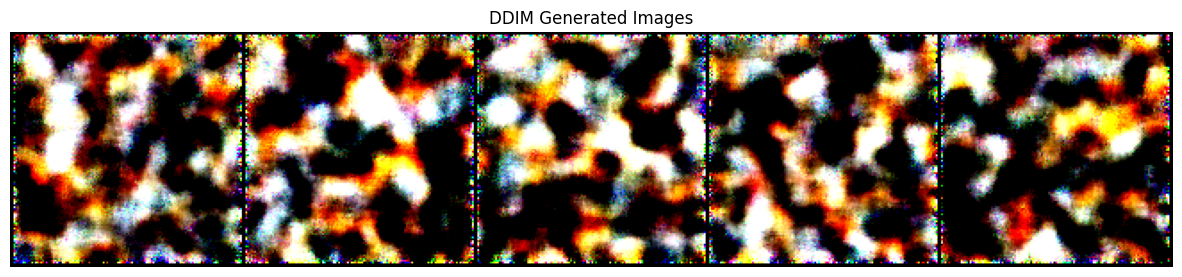

In [52]:
generated_imgs_tensor = ddim_sample(trained_model, scheduler, num_samples=5, img_size=128, channels=3)
show_generated_images(generated_imgs_tensor, title="DDIM Generated Images")

### Model Evaluation

In [53]:
fid_score, is_score = evaluate_generated_images(generated_images, train_loader)


📊 Evaluation Results:
✅ FID Score: 517.7107
✅ Inception Score: 0.0000


###  Interpretation of the Moderate U-Net, 1000 Samples

**Visual Quality**: Slight improvement in color richness, but still no object-level structure.

| Metric               | Value      |
|----------------------|------------|
| FID Score            | 517.71     |
| Inception Score      | 0.0000     |

**Interpretation**:
- Model still produces unstructured blobs without meaning.
- Inception Score of 0.0 means images are not classifiable or diverse.
- FID score worsened slightly compared to earlier runs.

**What Improved**:
- Color diversity is higher than previous black/white patterns.

**What Didn’t Improve**:
- Structure, realism, and semantic quality are still lacking.

**Next Steps**:
- Train on more data (full dataset)
- Add more depth (3–4 down/up levels)
- Reduce diffusion steps
- Consider label conditioning for control


##  **Iteration 3- Deep U-Net with 5 Levels + Skip Connections**

DEEPER DDIM TRAINING- To see if more data gives us better results we are going for a deeper DDIM model trained on a bigger sample of images.

### Define Model- Deep U-Net with 5 Levels + Skip Connections

In [56]:
class DDIMUNetDeep(nn.Module):
    def __init__(self, image_channels=3, base_channels=64, time_emb_dim=256):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )

        self.down1 = nn.Sequential(nn.Conv2d(image_channels, base_channels, 3, padding=1), nn.ReLU())
        self.down2 = nn.Sequential(nn.Conv2d(base_channels, base_channels*2, 4, 2, 1), nn.ReLU())
        self.down3 = nn.Sequential(nn.Conv2d(base_channels*2, base_channels*4, 4, 2, 1), nn.ReLU())
        self.down4 = nn.Sequential(nn.Conv2d(base_channels*4, base_channels*8, 4, 2, 1), nn.ReLU())
        self.down5 = nn.Sequential(nn.Conv2d(base_channels*8, base_channels*8, 4, 2, 1), nn.ReLU())

        self.middle = nn.Sequential(nn.Conv2d(base_channels*8, base_channels*8, 3, padding=1), nn.ReLU())
        self.time_proj = nn.Linear(time_emb_dim, base_channels * 8)

        self.up1 = nn.Sequential(nn.ConvTranspose2d(base_channels*8, base_channels*8, 4, 2, 1), nn.ReLU())
        self.up2 = nn.Sequential(nn.ConvTranspose2d(base_channels*16, base_channels*4, 4, 2, 1), nn.ReLU())
        self.up3 = nn.Sequential(nn.ConvTranspose2d(base_channels*8, base_channels*2, 4, 2, 1), nn.ReLU())
        self.up4 = nn.Sequential(nn.ConvTranspose2d(base_channels*4, base_channels, 4, 2, 1), nn.ReLU())
        self.final = nn.Conv2d(base_channels*2, image_channels, 1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        t_proj = self.time_proj(t_emb).unsqueeze(-1).unsqueeze(-1)

        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4) + t_proj

        m = self.middle(d5)
        u1 = self.up1(m)
        u2 = self.up2(torch.cat([u1, d4], dim=1))
        u3 = self.up3(torch.cat([u2, d3], dim=1))
        u4 = self.up4(torch.cat([u3, d2], dim=1))
        out = self.final(torch.cat([u4, d1], dim=1))
        return out


### Increased the sample size

In [62]:
sample_size = 3000
subset_indices = list(range(sample_size))  # Or use random.sample(...) for diversity
train_subset = Subset(train_dataset, subset_indices)
train_loader_sampled = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)

print(f"Sampled training set size: {len(train_subset)}")

Sampled training set size: 3000


### Instantiate the Model + Scheduler

In [63]:
model = DDIMUNetDeep(image_channels=3).to(device)
scheduler = LinearBetaScheduler(timesteps=1000)

### Model Training 

In [64]:
trained_model = train_ddim_model(model, train_loader_sampled, scheduler, num_epochs=100, patience=10)

Epoch [1/100] - Loss: 0.9322


Epoch [11/100] - Loss: 0.0935


Epoch [21/100] - Loss: 0.0651


Epoch [31/100] - Loss: 0.0555


Epoch [41/100] - Loss: 0.0490


Epoch [51/100] - Loss: 0.0513


Epoch [61/100] - Loss: 0.0481


Epoch [71/100] - Loss: 0.0441


⏹️ Early stopping at epoch 76
✅ Training complete. Best model was from epoch 66 with loss: 0.0407


### Generate Images 

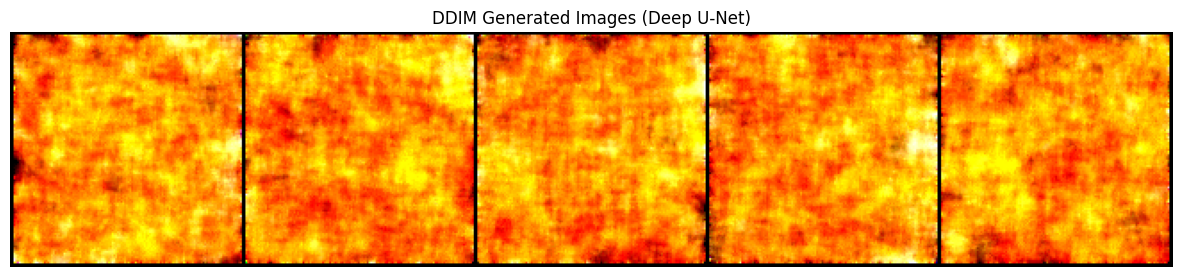

In [65]:
generated_imgs_tensor = ddim_sample(trained_model, scheduler, num_samples=5, img_size=128, channels=3)
show_generated_images(generated_imgs_tensor, title="DDIM Generated Images (Deep U-Net)")

### Evaluate the model 

In [66]:
generated_images = [img.permute(1, 2, 0).cpu().numpy() for img in generated_imgs_tensor]
fid_score, is_score = evaluate_generated_images(generated_images, train_loader)


📊 Evaluation Results:
✅ FID Score: 446.1724
✅ Inception Score: 0.0000


##  Interpretation of Deep U-Net DDIM Model

### Generated Samples
The generated images exhibit improved structure compared to earlier noisy outputs. While still abstract, they now show stronger texture consistency and less random noise, suggesting the deeper U-Net model (with skip connections) helped in capturing more meaningful representations.

---

###  Quantitative Metrics

| Metric            | Value     |
|-------------------|-----------|
|  FID Score       | **446.1724** |
|  Inception Score | **0.0000**   |

---

###  Interpretation

- **FID Score ↓ (Improved):**  
  The FID (Fréchet Inception Distance) score has **decreased** from previous values (e.g., 505 → 446), indicating that the generated images are **statistically closer to real images** in the training dataset. This suggests that the deeper model trained on more data was effective.

- **Inception Score = 0.0:**  
  This score remains **0.0**, which typically implies:
  - The generated images lack strong class-specific features, or
  - The Inception model's softmax outputs are not meaningful due to the nature of the data (e.g., blurry/unlabeled images).
  
  This may be expected in unsupervised setups or if the model hasn’t learned distinct semantic features.

---

###  Conclusion

The Deep U-Net model has clearly enhanced visual quality and FID, showing **positive progression** in training. While Inception Score remains 0, this is not uncommon in early-stage or unlabeled generative tasks. 

## Next Steps to consider : 
    
- Generating more samples for smoother evaluation,
- Adding label conditioning (e.g., class-conditional generation),
- fine-tuning with class-aware objectives for higher IS.